# Iris Dataset — прогнозування `Sepal width`

**Тип задачі:** регресія  
**Цільова змінна:** `Sepal width (cm)`  
**Ознаки:** `Sepal length (cm)`, `Petal length (cm)`, `Petal width (cm)`

## Мета

Дослідити, як збільшення складності поліноміальної регресії впливає на якість узагальнення, виявити ознаки перенавчання та перевірити, чи допомагає регуляризація Ridge та Elastic Net зменшити помилку, розрив узагальнення та нестабільність моделі.

> **Важливо:** test-вибірка не використовується для вибору ступеня полінома, `alpha` або `l1_ratio`. Вона застосовується лише один раз для фінальної оцінки обраних моделей.

**Методичні пункти:** 3. Контрольована шкала складності; 4. Діагностика недонавчання і перенавчання.


## 1. Перевірювані гіпотези

### H1. Вплив складності на train- та CV-похибки
Зі збільшенням ступеня полінома train RMSE буде зменшуватися, але CV RMSE після певного ступеня почне зростати.

**Обчислюємо:** mean train RMSE, mean CV RMSE, std CV RMSE, CV RMSE − train RMSE.  
**Графік:** залежність train/CV RMSE від ступеня полінома.  
**Підтвердження:** train RMSE падає, а CV RMSE має мінімум і далі зростає.  
**Спростування:** CV RMSE стабільно падає або не демонструє погіршення при рості складності.

### H2. Перенавчання з'являється на високій складності
Для достатньо великих ступенів очікується збільшення розриву між train RMSE та CV RMSE.

**Обчислюємо:** generalization gap = CV RMSE − train RMSE.  
**Графік:** generalization gap за ступенями.  
**Підтвердження:** gap різко збільшується на високих ступенях разом із CV RMSE.  
**Спростування:** gap залишається малим і не зростає.

### H3. Регуляризація покращує узагальнення та стійкість
Для поліномів підвищеної складності регуляризація Ridge/Elastic Net зменшить CV RMSE і generalization gap порівняно з нерегуляризованою моделлю, а Elastic Net додатково дасть простішу модель через занулення частини коефіцієнтів.

**Обчислюємо:** CV RMSE, std CV RMSE, generalization gap, test RMSE, test R², кількість ненульових коефіцієнтів та варіативність коефіцієнтів між CV-folds.  
**Таблиці/графіки:** порівняння моделей, CV RMSE за `alpha`, кількість ненульових коефіцієнтів і коефіцієнтна стабільність.  
**Підтвердження:** регуляризована модель має нижчий CV RMSE та/або gap; Elastic Net має меншу складність при зіставній якості; test RMSE не суперечить CV-оцінці.  
**Спростування:** регуляризація систематично погіршує CV RMSE без компенсації у gap/стабільності.


## 2. Фіксація експериментального протоколу

Протокол зафіксовано **до перегляду результатів основного експерименту**.

| Параметр | Зафіксоване значення |
|---|---|
| Джерело даних | `sklearn.datasets.load_iris(as_frame=True)` |
| Рядків | 150 |
| Числових ознак для прогнозу | 3 |
| Ціль | `Sepal width (cm)` |
| Train/Test | 80% / 20% |
| `random_state` | 42 |
| CV | 5-fold `KFold(shuffle=True, random_state=42)` |
| Основна метрика | RMSE, менше — краще |
| Додаткова метрика | R² |
| Початковий Pipeline | `PolynomialFeatures → StandardScaler → estimator` |
| Шкала складності | ступені 1–10 |
| Ridge `alpha` | `10^-4 ... 10^2` (7 логарифмічних значень) |
| Elastic Net `alpha` | `10^-4 ... 10^2` (7 значень) |
| Elastic Net `l1_ratio` | 0.1, 0.3, 0.5, 0.7, 0.9 |
| Критерій вибору | мінімальний mean CV RMSE; за близької якості — простіша/стійкіша модель |
| Початковий бюджет | 10 + 70 + 350 = **430 конфігурацій** |

**Правило зміни протоколу:** після першого запуску не змінюємо сітки або сімейство моделей лише через отримані результати. Будь-яке розширення можливе тільки як окремий, явно позначений дослідницький етап із причиною та фіксацією того, які результати вже були відомі.

Test-вибірка не використовується для вибору ступеня, `alpha` або `l1_ratio`.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
DEGREES = list(range(1, 11))
ALPHAS = np.logspace(-4, 2, 7)
L1_RATIOS = [0.1, 0.3, 0.5, 0.7, 0.9]

cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


## 3. Завантаження та первинний огляд даних

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()

df = df.rename(columns={
    "sepal length (cm)": "Sepal length",
    "sepal width (cm)": "Sepal width",
    "petal length (cm)": "Petal length",
    "petal width (cm)": "Petal width"
})

feature_cols = ["Sepal length", "Petal length", "Petal width"]
target_col = "Sepal width"

X = df[feature_cols]
y = df[target_col]

print(f"Розмір датасету: {df.shape}")
print("\nПропуски:")
print(df.isna().sum())
print("\nОпис:")
display(df.describe().round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"\nTrain: {X_train.shape[0]} рядків")
print(f"Test:  {X_test.shape[0]} рядків")


Розмір датасету: (150, 5)

Пропуски:
Sepal length    0
Sepal width     0
Petal length    0
Petal width     0
target          0
dtype: int64

Опис:


,Sepal length,Sepal width,Petal length,Petal width,target
count,150.000,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199,1.000
std,0.828,0.436,1.765,0.762,0.819
min,4.300,2.000,1.000,0.100,0.000
25%,5.100,2.800,1.600,0.300,0.000
50%,5.800,3.000,4.350,1.300,1.000
75%,6.400,3.300,5.100,1.800,2.000
max,7.900,4.400,6.900,2.500,2.000



Train: 120 рядків
Test:  30 рядків


**Що перевіряємо:** dataset містить 150 спостережень, а ціль `Sepal width` прогнозується за трьома іншими вимірюваннями. Якість даних контролюємо через пропуски та базову статистику.

## 4. Контрольована шкала складності

Для Iris після вилучення цільової змінної залишається лише **3 числові ознаки**. Категоріальні ознаки відсутні, тому `ColumnTransformer` не потрібен. Використовуються всі три доступні числові предиктори без штучного скорочення набору.

Для `PolynomialFeatures(degree=d, include_bias=False)` кількість сформованих ознак дорівнює

\[
N(d)=\binom{p+d}{d}-1,
\]

де `p=3` — кількість вхідних числових ознак. Перед запуском моделей кількість ознак перевіряється та порівнюється з консервативною оцінкою пам'яті для dense `float64`-матриці.

### 4.1. Попередня оцінка обсягу ознак


In [3]:
from math import comb

feature_budget_rows = []
for degree in DEGREES:
    n_features = comb(X_train.shape[1] + degree, degree) - 1
    dense_mb = X_train.shape[0] * n_features * 8 / (1024**2)
    feature_budget_rows.append({
        "degree": degree,
        "n_polynomial_features": n_features,
        "estimated_train_matrix_MB": dense_mb,
        "launch": dense_mb < 128
    })

feature_budget = pd.DataFrame(feature_budget_rows)
display(feature_budget)

max_features = int(feature_budget["n_polynomial_features"].max())
max_dense_mb = float(feature_budget["estimated_train_matrix_MB"].max())
print(f"Максимум: {max_features} ознак, орієнтовно {max_dense_mb:.3f} MB для однієї dense float64 train-матриці.")
print("Усі конфігурації дозволені до запуску: очікуваний обсяг значно нижчий за практичний ліміт 128 MB.")

cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def evaluate_cv(pipe):
    result = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        return_train_score=True,
        n_jobs=-1
    )
    train_rmse = -result["train_score"]
    cv_rmse = -result["test_score"]
    return {
        "train_rmse_mean": train_rmse.mean(),
        "cv_rmse_mean": cv_rmse.mean(),
        "cv_rmse_std": cv_rmse.std(ddof=1),
        "cv_rmse_se": cv_rmse.std(ddof=1) / np.sqrt(N_SPLITS),
        "gap": cv_rmse.mean() - train_rmse.mean(),
        "mean_fit_time_sec": result["fit_time"].mean(),
        "total_cv_time_sec": result["fit_time"].sum() + result["score_time"].sum()
    }

poly_rows = []
for degree in DEGREES:
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])
    r = evaluate_cv(pipe)
    r["degree"] = degree
    r["n_polynomial_features"] = int(feature_budget.loc[feature_budget.degree == degree, "n_polynomial_features"].iloc[0])
    poly_rows.append(r)

poly_results = pd.DataFrame(poly_rows).sort_values("degree")
display(poly_results.round(5))
poly_results.to_csv(FIG_DIR / "poly_results.csv", index=False)


,degree,n_polynomial_features,estimated_train_matrix_MB,launch
0,1,3,0.002747,True
1,2,9,0.008240,True
2,3,19,0.017395,True
3,4,34,0.031128,True
4,5,55,0.050354,True
5,6,83,0.075989,True
6,7,119,0.108948,True
7,8,164,0.150146,True
8,9,219,0.200500,True
9,10,285,0.260925,True


Максимум: 285 ознак, орієнтовно 0.261 MB для однієї dense float64 train-матриці.
Усі конфігурації дозволені до запуску: очікуваний обсяг значно нижчий за практичний ліміт 128 MB.


,train_rmse_mean,cv_rmse_mean,cv_rmse_std,cv_rmse_se,gap,mean_fit_time_sec,total_cv_time_sec,degree,n_polynomial_features
0,0.30072,0.30856,0.05876,0.02628,0.00785,0.17593,0.90877,1,3
1,0.24965,0.26822,0.04557,0.02038,0.01857,0.12421,0.65140,2,9
2,0.23677,0.32681,0.06674,0.02985,0.09004,0.02159,0.14454,3,19
3,0.20887,0.37213,0.11630,0.05201,0.16326,0.02211,0.15208,4,34
4,0.19013,0.66383,0.42294,0.18914,0.47370,0.01570,0.10707,5,55
5,0.17638,0.85101,0.67440,0.30160,0.67463,0.01377,0.09797,6,83
6,0.16789,1.07212,0.89344,0.39956,0.90423,0.01492,0.10261,7,119
7,0.16181,1.85935,1.43002,0.63952,1.69754,0.01606,0.10625,8,164
8,0.15480,2.55443,2.02319,0.90480,2.39964,0.01908,0.13117,9,219
9,0.15384,3.22914,2.79190,1.24858,3.07531,0.02653,0.19226,10,285


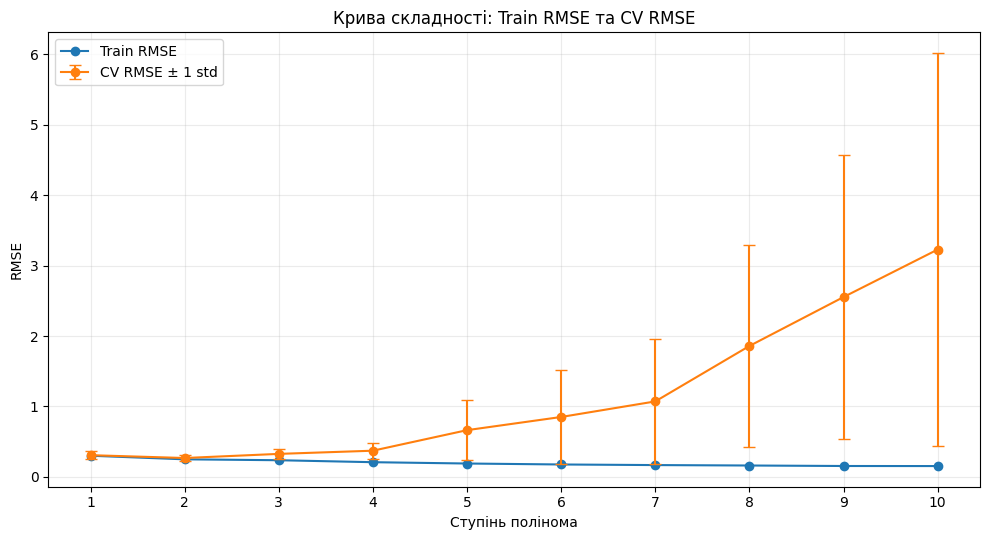

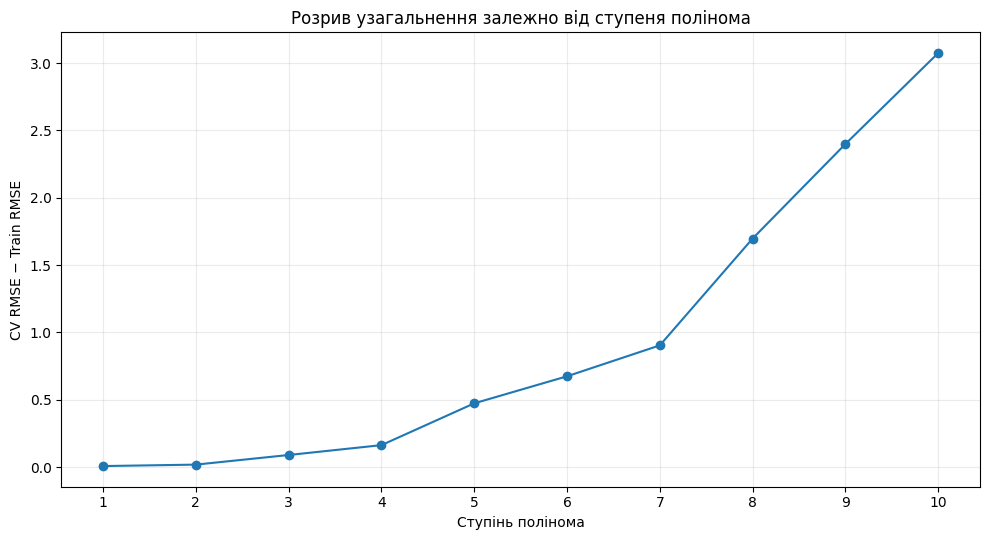

,degree,n_features,train_rmse_mean,cv_rmse_mean,cv_rmse_std,cv_rmse_se,generalization_gap,mean_fit_time_sec,total_cv_time_sec
0,1,3,0.30072,0.30856,0.05876,0.02628,0.00785,0.17593,0.90877
1,2,9,0.24965,0.26822,0.04557,0.02038,0.01857,0.12421,0.65140
2,3,19,0.23677,0.32681,0.06674,0.02985,0.09004,0.02159,0.14454
3,4,34,0.20887,0.37213,0.11630,0.05201,0.16326,0.02211,0.15208
4,5,55,0.19013,0.66383,0.42294,0.18914,0.47370,0.01570,0.10707
5,6,83,0.17638,0.85101,0.67440,0.30160,0.67463,0.01377,0.09797
6,7,119,0.16789,1.07212,0.89344,0.39956,0.90423,0.01492,0.10261
7,8,164,0.16181,1.85935,1.43002,0.63952,1.69754,0.01606,0.10625
8,9,219,0.15480,2.55443,2.02319,0.90480,2.39964,0.01908,0.13117
9,10,285,0.15384,3.22914,2.79190,1.24858,3.07531,0.02653,0.19226


In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(poly_results["degree"], poly_results["train_rmse_mean"], marker="o", label="Train RMSE")
ax.errorbar(
    poly_results["degree"], poly_results["cv_rmse_mean"],
    yerr=poly_results["cv_rmse_std"],
    fmt="o-", capsize=4, label="CV RMSE ± 1 std"
)
ax.set_title("Крива складності: Train RMSE та CV RMSE")
ax.set_xlabel("Ступінь полінома")
ax.set_ylabel("RMSE")
ax.set_xticks(DEGREES)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "01_complexity_train_vs_cv_rmse.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(poly_results["degree"], poly_results["gap"], marker="o")
ax.set_title("Розрив узагальнення залежно від ступеня полінома")
ax.set_xlabel("Ступінь полінома")
ax.set_ylabel("CV RMSE − Train RMSE")
ax.set_xticks(DEGREES)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_generalization_gap.png", dpi=160)
plt.show()

# окрема компактна таблиця для пункту 4 методички
poly_diagnostic_table = poly_results[[
    "degree", "n_polynomial_features", "train_rmse_mean",
    "cv_rmse_mean", "cv_rmse_std", "cv_rmse_se", "gap",
    "mean_fit_time_sec", "total_cv_time_sec"
]].copy()
poly_diagnostic_table.columns = [
    "degree", "n_features", "train_rmse_mean", "cv_rmse_mean",
    "cv_rmse_std", "cv_rmse_se", "generalization_gap",
    "mean_fit_time_sec", "total_cv_time_sec"
]
display(poly_diagnostic_table.round(5))
poly_diagnostic_table.to_csv(FIG_DIR / "poly_diagnostic_table.csv", index=False)


### 4.2. Діагностика недонавчання та перенавчання

- **Недонавчання:** область малих ступенів, де train RMSE і CV RMSE обидві залишаються відносно високими, а збільшення ступеня дає помітне покращення CV RMSE.
- **Найкраще узагальнення:** ступінь із мінімальним mean CV RMSE; додатково враховуємо `±1 std` та стандартну похибку середнього `SE = std / √5`.
- **Перенавчання:** область, де train RMSE продовжує зменшуватися, але CV RMSE та generalization gap зростають.
- **Стійкість висновку:** оцінюємо не лише середнє CV RMSE, а й стандартне відхилення/SE між однаковими 5 folds.

У цьому dataset повний контрольований stress test не потрібен: максимум дорівнює лише 285 поліноміальним ознакам для 3 вхідних числових ознак, тому шкала 1–10 є достатньо складною для перевірки перенавчання без необґрунтованого ризику пам'яті або часу виконання.


In [5]:
ridge_pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_grid = {
    "poly__degree": DEGREES,
    "model__alpha": ALPHAS
}

ridge_search = GridSearchCV(
    ridge_pipe,
    ridge_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=-1,
    refit=True
)
ridge_search.fit(X_train, y_train)

ridge_cv = pd.DataFrame(ridge_search.cv_results_)
ridge_cv["cv_rmse"] = -ridge_cv["mean_test_score"]
ridge_cv["train_rmse"] = -ridge_cv["mean_train_score"]
ridge_cv["gap"] = ridge_cv["cv_rmse"] - ridge_cv["train_rmse"]

ridge_table = ridge_cv[
    ["param_poly__degree", "param_model__alpha", "train_rmse", "cv_rmse", "gap"]
].sort_values("cv_rmse").head(15)

display(ridge_table.round(5))
print("Найкращий Ridge:", ridge_search.best_params_)
print("CV RMSE:", round(-ridge_search.best_score_, 5))


,param_poly__degree,param_model__alpha,train_rmse,cv_rmse,gap
32,3,0.1000,0.24852,0.25899,0.01047
31,2,0.1000,0.25359,0.25915,0.00556
43,4,1.0000,0.25440,0.25944,0.00504
44,5,1.0000,0.25174,0.25952,0.00779
33,4,0.1000,0.24709,0.26231,0.01522
45,6,1.0000,0.25087,0.26244,0.01157
21,2,0.0100,0.25010,0.26339,0.01329
42,3,1.0000,0.25984,0.26386,0.00403
22,3,0.0100,0.24587,0.26528,0.01940
46,7,1.0000,0.25054,0.26660,0.01607


Найкращий Ridge: {'model__alpha': np.float64(0.1), 'poly__degree': 3}
CV RMSE: 0.25899


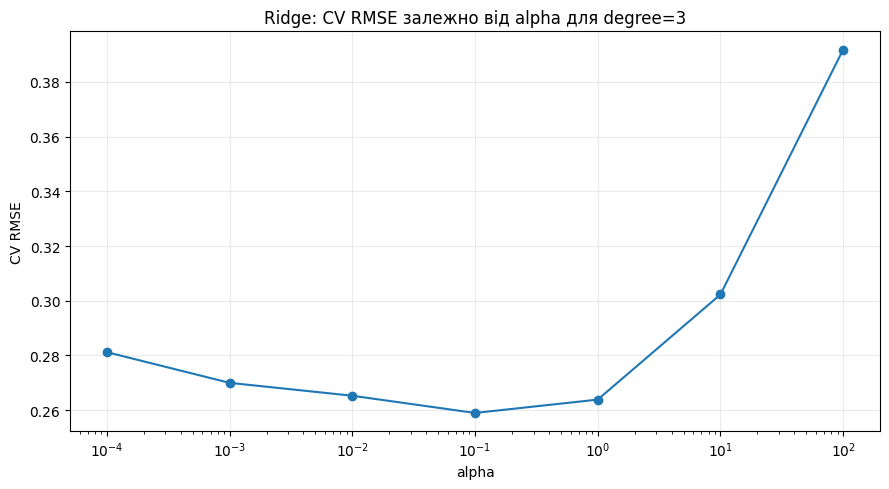

In [6]:
ridge_d3 = ridge_cv[ridge_cv["param_poly__degree"] == 3].copy()
ridge_d3["alpha"] = ridge_d3["param_model__alpha"].astype(float)
ridge_d3 = ridge_d3.sort_values("alpha")

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(ridge_d3["alpha"], ridge_d3["cv_rmse"], marker="o")
ax.set_title("Ridge: CV RMSE залежно від alpha для degree=3")
ax.set_xlabel("alpha")
ax.set_ylabel("CV RMSE")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_ridge_alpha_cv_rmse.png", dpi=160)
plt.show()
